# Introduction to Seaborn

Seaborn is a Python data visualization library built on top of Matplotlib that helps create attractive and informative statistical graphs with less code.

## Distribution plots

Distribution plots are used to understand how data is spread or distributed.

* distplot
* jointplot
* pairplot
* rugplot
* kdeplot

**They help identify:**

* Shape (normal, skewed)
* Outliers
* Frequency of values

## Imports

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
#import matplotlib.pyplot as plt

## Data

Seaborn comes with built-in data sets!

In [3]:
tips = sns.load_dataset('tips')

In [4]:
tips.head()
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## Distplot
The distplot shows the distribution of a univariate set of observations.

C:\Users\Admin\AppData\Local\Temp\ipykernel_21968\2698289874.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'],color='blue')


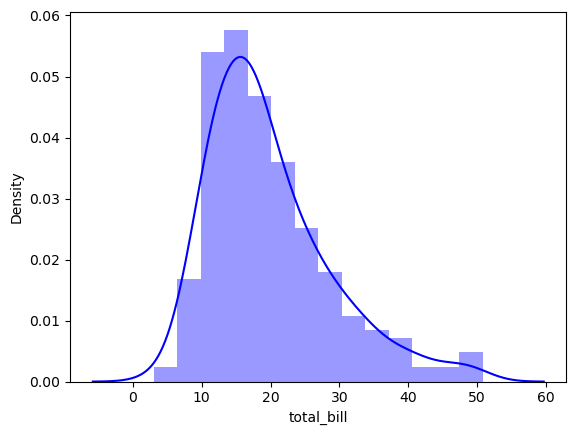

In [7]:
sns.distplot(tips['total_bill'],color='blue')
# Safe to ignore warnings

plt.show()

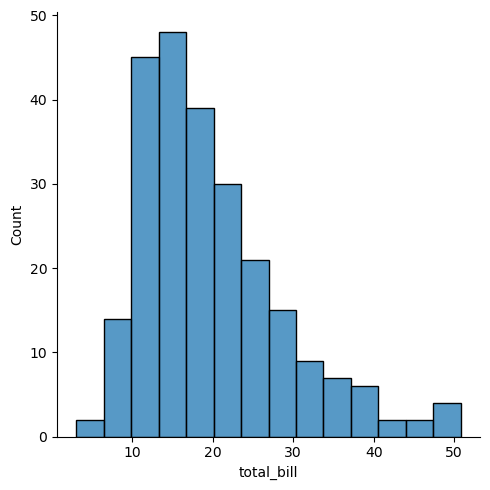

In [11]:
sns.displot(tips['total_bill'])

plt.show()

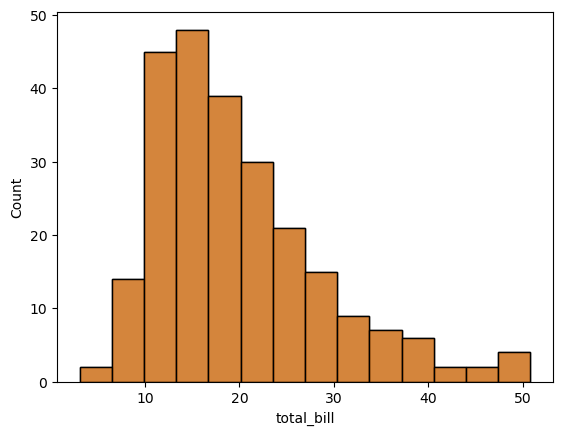

In [13]:
sns.histplot(tips['total_bill'])

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_21968\3812570254.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'],kde=False,bins=50,hist=True)


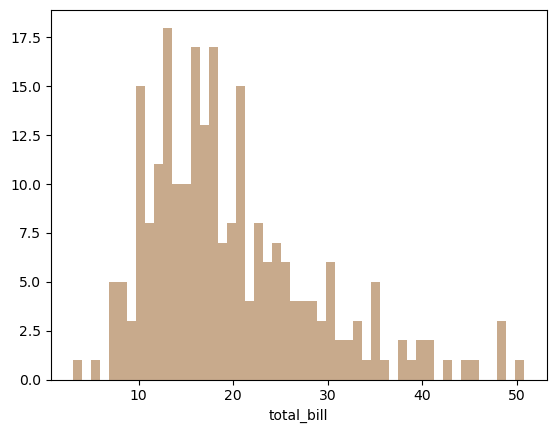

In [15]:
sns.distplot(tips['total_bill'],kde=False,bins=50,hist=True)

plt.show()

#plt.grid()

## jointplot

jointplot() is used to visualize the relationship between two variables along with their individual distributions.

jointplot() allows you to basically match up two distplots for bivariate data. With your choice of what **kind** parameter to compare with: 
* “scatter” 
* “reg” 
* “resid” 
* “kde” 
* “hex”


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.jointplot(data=df, x='column1', y='column2')
plt.show()

NameError: name 'df' is not defined

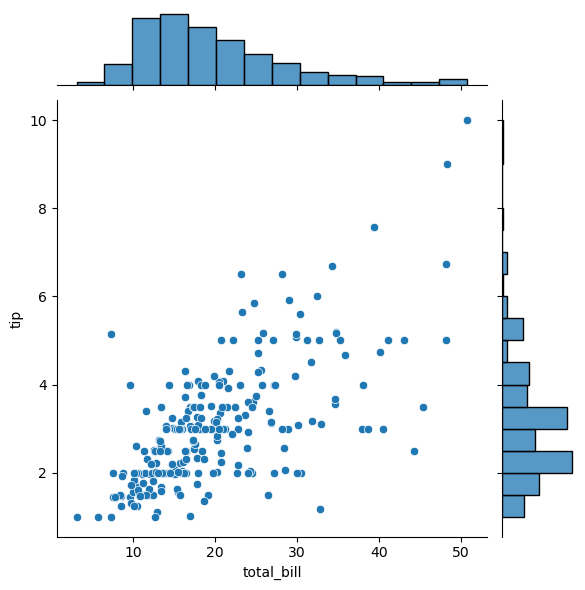

In [23]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='scatter')
plt.show()

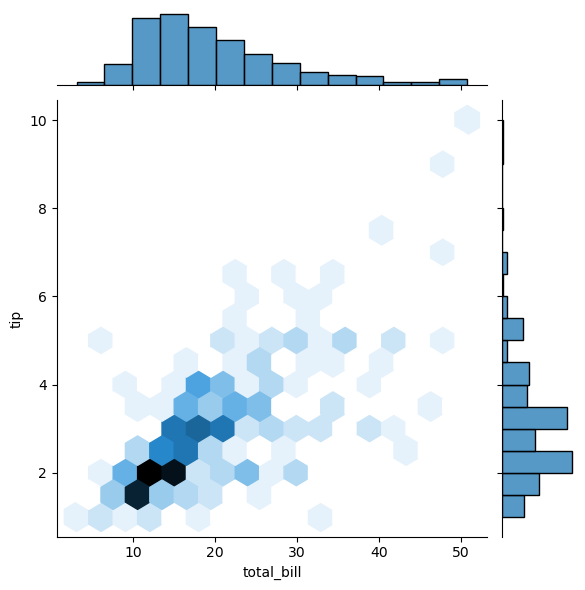

In [26]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='hex')
plt.show()

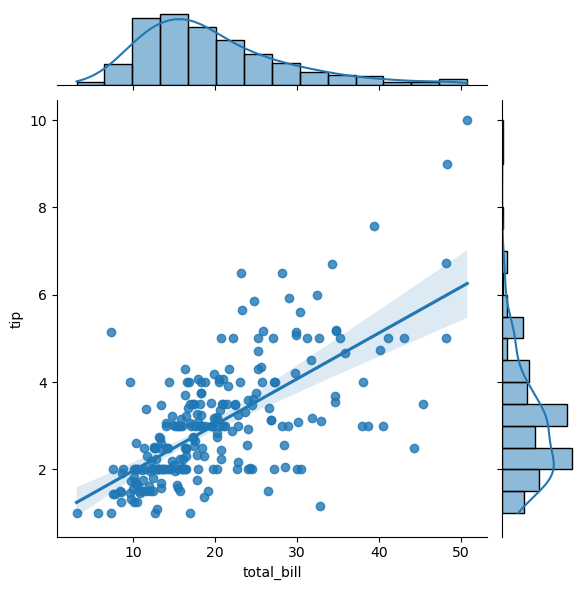

In [27]:
sns.jointplot(x='total_bill',y='tip',data=tips,kind='reg')
plt.show()

## Pair Plot
pairplot will plot pairwise relationships across an entire dataframe (for the numerical columns) and supports a color hue argument (for categorical columns).

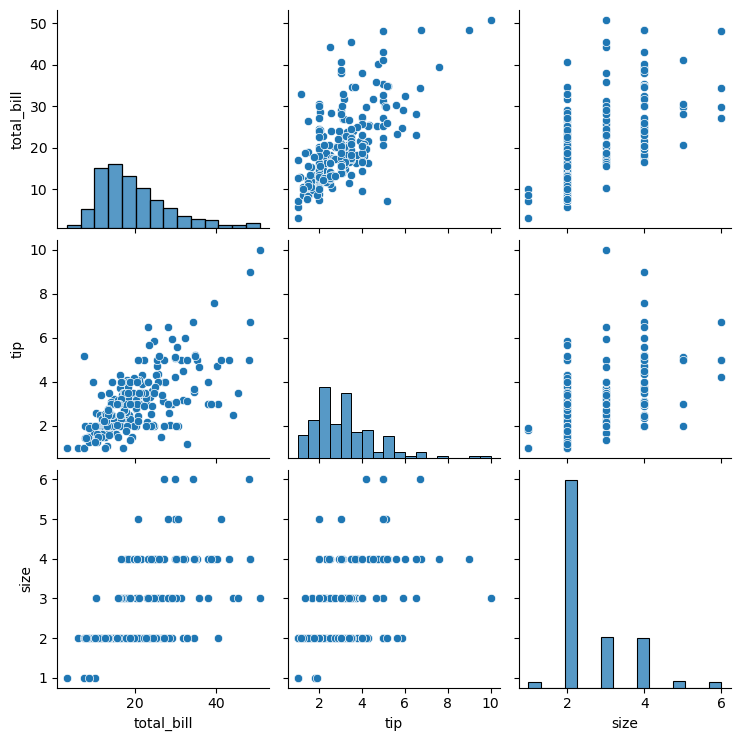

In [7]:
sns.pairplot(tips)
plt.show()

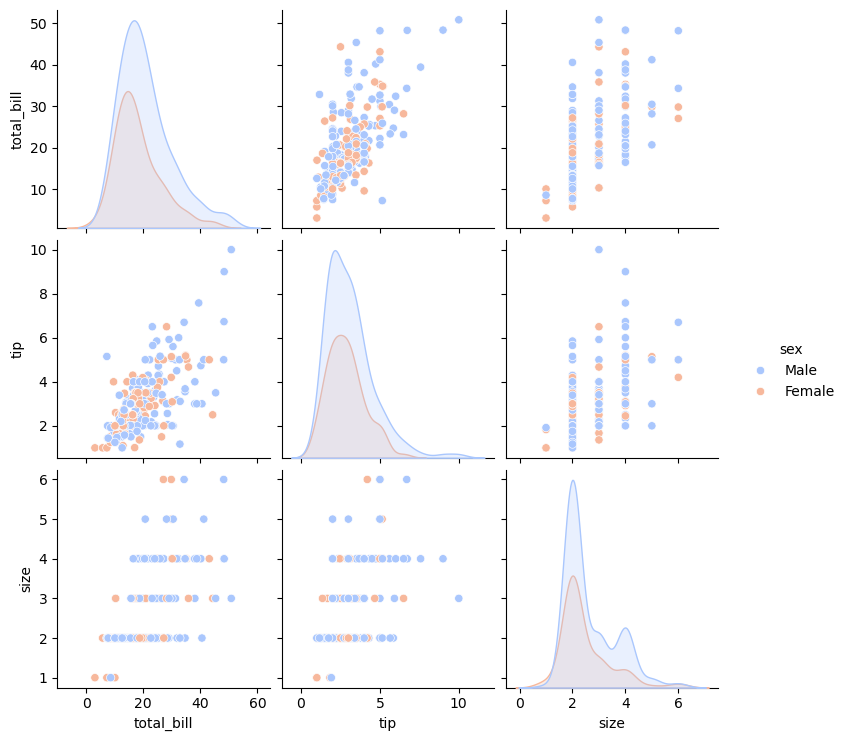

In [8]:
sns.pairplot(tips,hue='sex',palette='coolwarm')
plt.show()

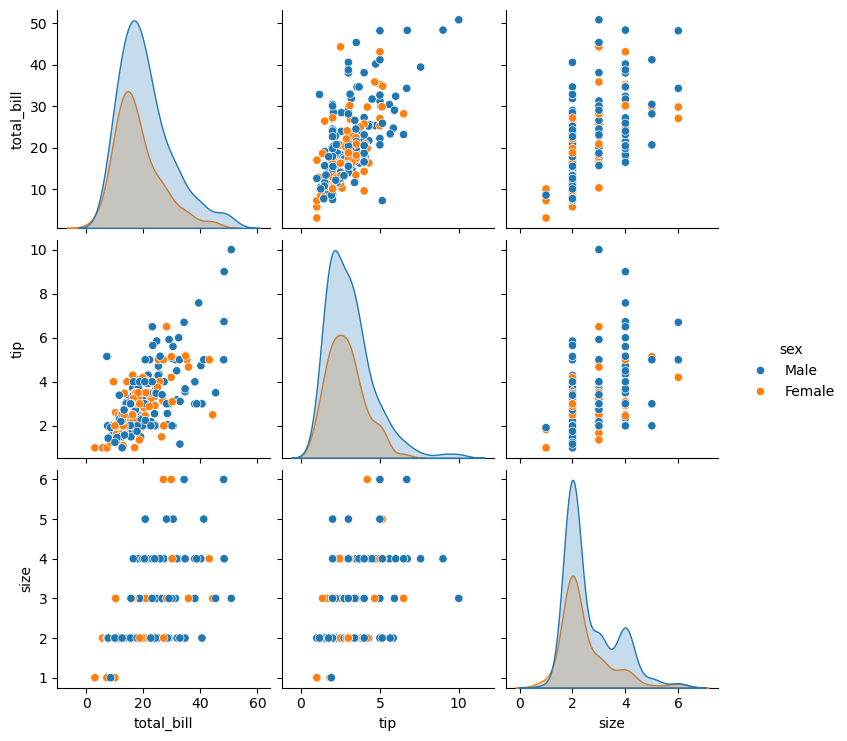

In [9]:
sns.pairplot(tips,hue='sex')
plt.show()

## Rugplot
Rugplots are actually a very simple concept, they just draw a dash mark for every point on a univariate distribution. They are the building block of a KDE plot:

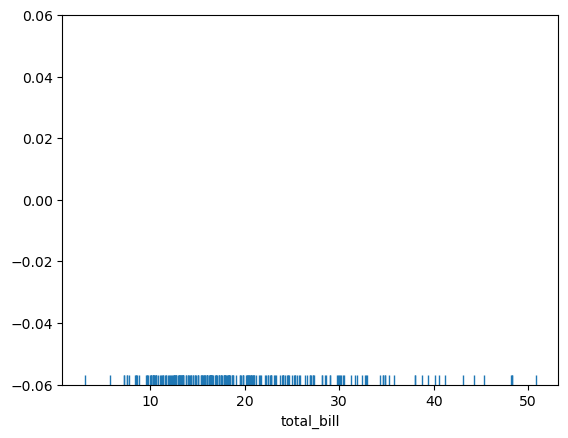

In [10]:
sns.rugplot(tips['total_bill'])
plt.show()

## Kdeplot
Kdeplots are Kernel Density Estimation plots. These KDE plots replace every single observation with a Gaussian (Normal) distribution centered around that value. For example:



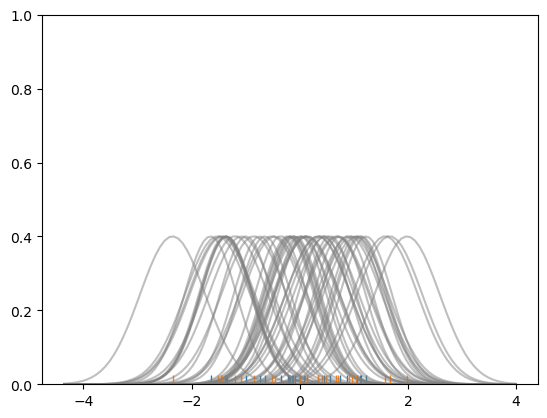

In [13]:
# Don't worry about understanding this code!
# It's just for the diagram below
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#Create dataset
dataset = np.random.randn(25)

# Create another rugplot
sns.rugplot(dataset);

# Set up the x-axis for the plot
x_min = dataset.min() - 2
x_max = dataset.max() + 2

# 100 equally spaced points from x_min to x_max
x_axis = np.linspace(x_min,x_max,100)

# Set up the bandwidth, for info on this:
url = 'http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth'

bandwidth = ((4*dataset.std()**5)/(3*len(dataset)))**.2


# Create an empty kernel list
kernel_list = []

# Plot each basis function
for data_point in dataset:
    
    # Create a kernel for each point and append to list
    kernel = stats.norm(data_point,bandwidth).pdf(x_axis)
    kernel_list.append(kernel)
    
    #Scale for plotting
    kernel = kernel / kernel.max()
    kernel = kernel * .4
    plt.plot(x_axis,kernel,color = 'grey',alpha=0.5)

plt.ylim(0,1)
plt.show()

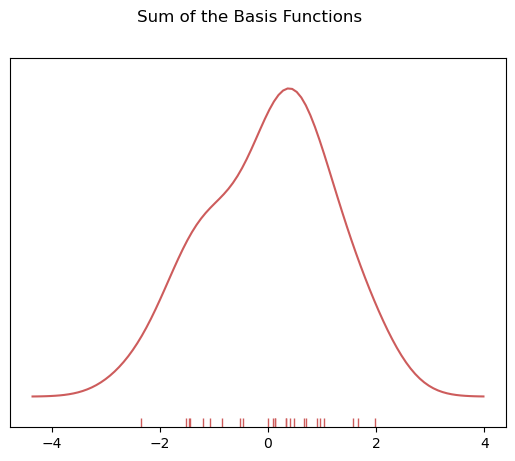

In [14]:
# To get the kde plot we can sum these basis functions.

# Plot the sum of the basis function
sum_of_kde = np.sum(kernel_list,axis=0)

# Plot figure
fig = plt.plot(x_axis,sum_of_kde,color='indianred')

# Add the initial rugplot
sns.rugplot(dataset,c = 'indianred')

# Get rid of y-tick marks
plt.yticks([])

# Set title
plt.suptitle("Sum of the Basis Functions")
plt.show()

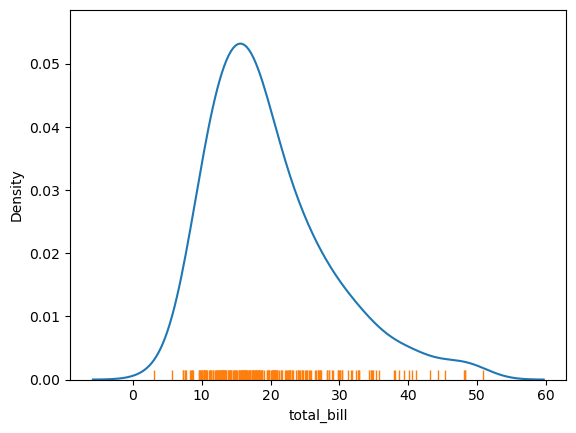

In [15]:
sns.kdeplot(tips['total_bill'])
sns.rugplot(tips['total_bill'])
plt.show()

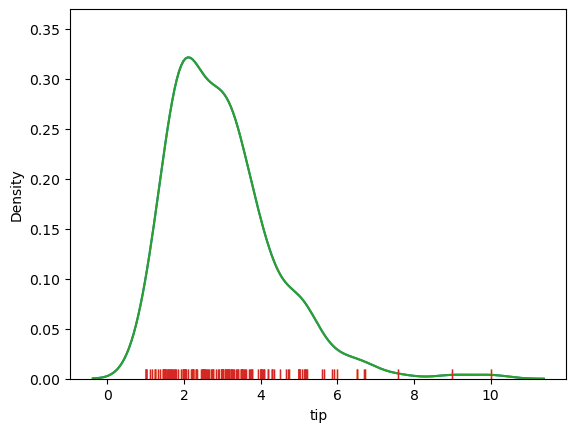

In [17]:
sns.kdeplot(tips['tip'])
sns.rugplot(tips['tip'])
plt.show()